# Lab 3 — Wielowarstwowe sieci jednokierunkowe i propagacja wsteczna

**Wybrane Zagadnienia Sztucznej Inteligencji · II stopień**

---

## Co zrobimy na tym labie

1. **Problem XOR** — przypomnijmy dlaczego perceptron się poddaje
2. **Od perceptronu do MLP** — dodajemy warstwę ukrytą i zmieniamy świat
3. **Funkcje aktywacyjne** — sigmoid i tanh (z pochodnymi!)
4. **Forward pass** — jak sygnał przepływa przez sieć
5. **Backpropagation** — jak sieć się uczy (aktualizacja wag)
6. **DEMO: XOR rozwiązany!** — to co perceptron nie mógł, MLP potrafi
7. **Zadania samodzielne**

**Używamy wyłącznie numpy** — budujemy sieć od zera, bez frameworków.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Gotowe. numpy + matplotlib zaladowane.")

Gotowe. numpy + matplotlib zaladowane.


---

## 1. Przypomnienie: XOR — granica perceptronu

Na Lab 2 widzieliśmy, że perceptron **nie umie** nauczyć się XOR:

| x1 | x2 | XOR |
|----|----|----|  
| 0  | 0  | 0  |
| 0  | 1  | 1  |
| 1  | 0  | 1  |
| 1  | 1  | 0  |

Dlaczego? Bo XOR **nie jest liniowo separowalny** — nie da się narysować jednej prostej, która rozdzieli klasy. Perceptron = jedna prosta = za mało.

**Rozwiązanie:** Dodajemy **warstwę ukrytą**. Dwie proste zamiast jednej. To jest **MLP** (Multilayer Perceptron).

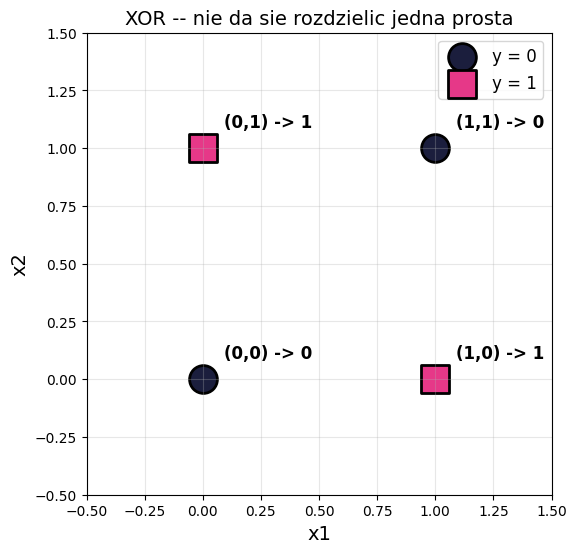

Perceptron nie da rady. Potrzebujemy WIECEJ niz jednej prostej.


In [2]:
# Dane XOR -- zobaczmy je
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

plt.figure(figsize=(6, 6))
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1],
            c='#1B1E3D', marker='o', s=400, label='y = 0', edgecolor='black', linewidth=2)
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1],
            c='#E63888', marker='s', s=400, label='y = 1', edgecolor='black', linewidth=2)
for x, y_val in zip(X_xor, y_xor):
    plt.annotate(f'({x[0]},{x[1]}) -> {y_val}', (x[0], x[1]),
                 textcoords='offset points', xytext=(15, 15), fontsize=12, fontweight='bold')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel('x1', fontsize=14)
plt.ylabel('x2', fontsize=14)
plt.title('XOR -- nie da sie rozdzielic jedna prosta', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()
print('Perceptron nie da rady. Potrzebujemy WIECEJ niz jednej prostej.')

---

## 2. Od perceptronu do MLP

**MLP (Multilayer Perceptron)** składa się z:
- **Warstwa wejściowa** — przyjmuje dane (x1, x2, ...)
- **Warstwa(y) ukryta(e)** — przetwarza sygnały, każdy neuron ma swoje wagi
- **Warstwa wyjściowa** — daje końcową odpowiedź

Sygnał płynie **w jednym kierunku**: wejście → ukryta → wyjście (stąd: *jednokierunkowa*).

### Kluczowa różnica vs perceptron

| | Perceptron | MLP |
|---|---|---|
| Warstwy | 1 (wejście → wyjście) | 2+ (wejście → ukryta → wyjście) |
| Granica decyzyjna | Prosta/płaszczyzna | Dowolny kształt (nieliniowa!) |
| Funkcja aktywacji | Progowa (step) | Ciągła (sigmoid, tanh) |
| XOR? | Nie | Tak |
| Uczenie | Reguła perceptronu | Propagacja wsteczna (backpropagation) |

### Architektura naszej sieci (z instrukcji)

Dla dzisiejszego laba budujemy sieć z **1 warstwą ukrytą**:

```
Wejście (N)  →  Warstwa ukryta (K neuronów, tanh)  →  Wyjście (M neuronów, sigmoid)
     x            W¹ (K x N+1)         v              W² (M x K+1)        y
```

- **x** = `[1, x1, x2, ..., xN]` — wejście z biasem (x0=1)
- **W¹** = macierz wag wejście → ukryta
- **v** = wyjścia warstwy ukrytej (po tanh)
- **W²** = macierz wag ukryta → wyjście
- **y** = wyjście sieci (po sigmoid)

---

## 3. Funkcje aktywacyjne

Dlaczego nie używamy funkcji progowej (step) jak w perceptronie? Bo **nie da się policzyć jej pochodnej** (jest nieciągła w zerze). A backpropagation potrzebuje pochodnych.

Zamiast tego używamy **ciągłych** funkcji sigmoidalnych:

### Sigmoid (unipolarna, zakres 0–1)

$$\sigma(x) = \frac{1}{1 + e^{-\beta x}}$$

Pochodna: $\sigma'(x) = \beta \cdot \sigma(x) \cdot (1 - \sigma(x))$

### Tanh (bipolarna, zakres -1–1)

$$\tanh(x) = \frac{e^{\beta x} - e^{-\beta x}}{e^{\beta x} + e^{-\beta x}}$$

Pochodna: $\tanh'(x) = \beta \cdot (1 - \tanh^2(x))$

Parametr $\beta$ kontroluje nachylenie (zwykle $\beta = 1$).

In [3]:
# Implementacja funkcji aktywacyjnych
def sigmoid(x, beta=1.0):
    return 1.0 / (1.0 + np.exp(-beta * x))

def sigmoid_derivative(y, beta=1.0):
    """Pochodna sigmoidy. UWAGA: y to juz WYJSCIE sigmoidy, nie x!"""
    return beta * y * (1 - y)

def tanh_act(x, beta=1.0):
    return np.tanh(beta * x)

def tanh_derivative(y, beta=1.0):
    """Pochodna tanh. UWAGA: y to juz WYJSCIE tanh, nie x!"""
    return beta * (1 - y**2)

print("Funkcje aktywacyjne zdefiniowane.")

Funkcje aktywacyjne zdefiniowane.


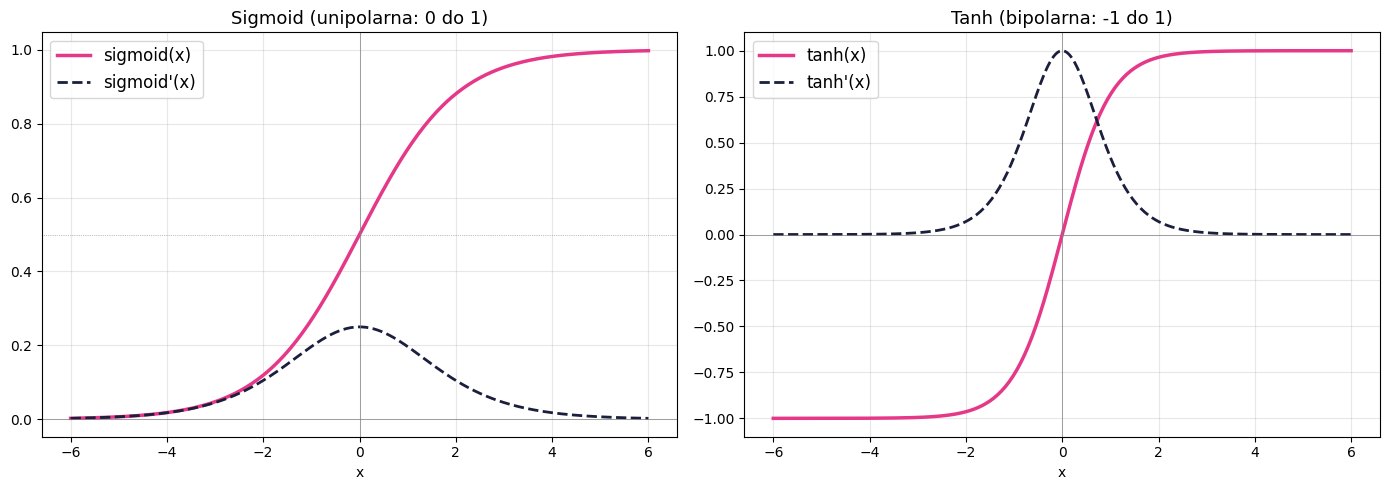

Sigmoid: wyjscie 0-1 (dobre dla prawdopodobienstw)
Tanh: wyjscie -1 do 1 (centrowane wokol zera, lepsze gradienty)
Pochodne -- sa cigle i latwe do obliczenia. To klucz do backpropagation.


In [4]:
# Wizualizacja funkcji aktywacyjnych i ich pochodnych
x = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoid
y_sig = sigmoid(x)
y_sig_deriv = sigmoid_derivative(y_sig)
axes[0].plot(x, y_sig, color='#E63888', linewidth=2.5, label='sigmoid(x)')
axes[0].plot(x, y_sig_deriv, color='#1B1E3D', linewidth=2, linestyle='--', label="sigmoid'(x)")
axes[0].set_title('Sigmoid (unipolarna: 0 do 1)', fontsize=13)
axes[0].axhline(0.5, color='gray', linewidth=0.5, linestyle=':')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].set_xlabel('x')

# Tanh
y_tanh = tanh_act(x)
y_tanh_deriv = tanh_derivative(y_tanh)
axes[1].plot(x, y_tanh, color='#E63888', linewidth=2.5, label='tanh(x)')
axes[1].plot(x, y_tanh_deriv, color='#1B1E3D', linewidth=2, linestyle='--', label="tanh'(x)")
axes[1].set_title('Tanh (bipolarna: -1 do 1)', fontsize=13)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].set_xlabel('x')

plt.tight_layout()
plt.show()

print("Sigmoid: wyjscie 0-1 (dobre dla prawdopodobienstw)")
print("Tanh: wyjscie -1 do 1 (centrowane wokol zera, lepsze gradienty)")
print("Pochodne -- sa cigle i latwe do obliczenia. To klucz do backpropagation.")

---

## 4. Forward pass — jak sygnał płynie przez sieć

Forward pass to obliczenie wyjścia sieci dla danego wejścia. Krok po kroku:

1. **Wejście** x = [1, x1, x2] (jedynka na początku to bias)
2. **Warstwa ukryta**: v_k = tanh( suma(w¹_kn * x_n) ) dla każdego neuronu k
3. **Dodaj bias** do v: v = [1, v1, v2, ..., vK]
4. **Warstwa wyjściowa**: y_m = sigmoid( suma(w²_mk * v_k) )

W formie macierzowej:
```
v = tanh(W¹ @ x)       # wyjścia ukrytej
v = [1, v1, ..., vK]   # dodajemy bias
y = sigmoid(W² @ v)    # wyjście sieci
```

`

In [5]:
# DEMO: forward pass krok po kroku

# Architektura: 2 wejscia, 2 neurony ukryte, 1 wyjscie
# Wagi losowe (male)
np.random.seed(42)
W1 = np.random.randn(2, 3) * 0.5   # 2 neurony ukryte x 3 wejscia (bias + x1 + x2)
W2 = np.random.randn(1, 3) * 0.5   # 1 neuron wyjsciowy x 3 wejscia (bias + v1 + v2)
beta = 1.0

print("Wagi W1 (wejscie -> ukryta):")
print(W1)
print(f"\nWagi W2 (ukryta -> wyjscie):")
print(W2)

# Jeden przyklad: x = [0, 1] (XOR powinien dac 1)
x_input = np.array([0, 1])
x = np.array([1, x_input[0], x_input[1]])  # dodajemy bias x0=1

print(f"\n=== Forward pass dla x = {x_input} ===")
print(f"Krok 1: x z biasem = {x}")

# Warstwa ukryta
z_hidden = W1 @ x                  # suma wazona
v_hidden = tanh_act(z_hidden, beta)  # aktywacja tanh
print(f"Krok 2: z_hidden (suma wazona) = {z_hidden}")
print(f"Krok 3: v_hidden (po tanh)     = {v_hidden}")

# Dodajemy bias do warstwy ukrytej
v = np.concatenate([[1], v_hidden])  # v0=1 (bias)
print(f"Krok 4: v z biasem             = {v}")

# Warstwa wyjsciowa
z_output = W2 @ v                    # suma wazona
y_output = sigmoid(z_output, beta)    # aktywacja sigmoid
print(f"Krok 5: z_output (suma wazona) = {z_output}")
print(f"Krok 6: y_output (po sigmoid)  = {y_output}")

print(f"\nSiec odpowiada: {y_output[0]:.4f} (oczekiwane: 1 dla XOR(0,1))")
print("Wagi sa losowe, wiec odpowiedz jest przypadkowa. Musimy NAUCZYC siec.")

Wagi W1 (wejscie -> ukryta):
[[ 0.24835708 -0.06913215  0.32384427]
 [ 0.76151493 -0.11707669 -0.11706848]]

Wagi W2 (ukryta -> wyjscie):
[[ 0.78960641  0.38371736 -0.23473719]]

=== Forward pass dla x = [0 1] ===
Krok 1: x z biasem = [1 0 1]
Krok 2: z_hidden (suma wazona) = [0.57220135 0.64444645]
Krok 3: v_hidden (po tanh)     = [0.51697412 0.56791948]
Krok 4: v z biasem             = [1.         0.51697412 0.56791948]
Krok 5: z_output (suma wazona) = [0.85466653]
Krok 6: y_output (po sigmoid)  = [0.70154514]

Siec odpowiada: 0.7015 (oczekiwane: 1 dla XOR(0,1))
Wagi sa losowe, wiec odpowiedz jest przypadkowa. Musimy NAUCZYC siec.


---

## 5. Backpropagation — jak sieć się uczy

Algorytm propagacji wstecznej w 4 krokach:

1. **Inicjalizacja wag** — małe losowe wartości
2. **Obliczenie błędu** — forward pass + porównanie z oczekiwaną wartością (MSE)
3. **Obliczenie gradientu** — jak zmienić każdą wagę, żeby zmniejszyć błąd (reguła łańcuchowa)
4. **Aktualizacja wag** — w₂ = w₂ - η * gradient

### Funkcja błędu (MSE)

$$E(W) = \frac{1}{2} \sum_{m=1}^{M} (y_m - d_m)^2$$

### Gradient dla warstwy wyjściowej (W²)

$$\frac{\partial E}{\partial w^{(2)}_{mk}} = (y_m - d_m) \cdot G'\left(\sum_k w^{(2)}_{mk} \cdot v_k\right) \cdot v_k$$

### Gradient dla warstwy ukrytej (W¹)

$$\frac{\partial E}{\partial w^{(1)}_{kn}} = \sum_{m} (y_m - d_m) \cdot G'(\cdot) \cdot w^{(2)}_{mk} \cdot F'\left(\sum_n w^{(1)}_{kn} \cdot x_n\right) \cdot x_n$$

Wygląda strasznie, ale w kodzie to kilka mnożeń macierzowych.

---

## 6. DEMO — MLP rozwiązuje XOR!

Teraz złożymy wszystko razem: forward pass + backpropagation + pętla treningowa.

Architektura: **2 wejścia → 2 neurony ukryte (tanh) → 1 wyjście (sigmoid)**

In [6]:
def mlp_forward(x, W1, W2, beta=1.0):
    """
    Forward pass przez MLP.
    x:  wektor wejsciowy [1, x1, x2, ..., xN] (z biasem!)
    W1: macierz wag warstwy ukrytej (K x N+1)
    W2: macierz wag warstwy wyjsciowej (M x K+1)
    
    Zwraca: y (wyjscie), v (wyjscia ukrytej z biasem), z_hidden, z_output
    """
    # Warstwa ukryta
    z_hidden = W1 @ x
    v_hidden = tanh_act(z_hidden, beta)
    v = np.concatenate([[1], v_hidden])  # bias v0=1
    
    # Warstwa wyjsciowa
    z_output = W2 @ v
    y = sigmoid(z_output, beta)
    
    return y, v, v_hidden, z_hidden, z_output

print("mlp_forward() zdefiniowane.")

mlp_forward() zdefiniowane.


In [7]:
def train_mlp_xor(X, d, eta=0.5, beta=1.0, epochs=10000, verbose=True):
    """
    Trenuje MLP na danych XOR.
    X: dane wejsciowe (4x2 dla XOR)
    d: oczekiwane wyjscia (4,)
    eta: wspolczynnik uczenia
    epochs: maksymalna liczba epok
    """
    N = X.shape[1]  # liczba wejsc
    K = 2           # neurony ukryte
    M = 1           # neurony wyjsciowe
    
    # Inicjalizacja wag (male losowe)
    np.random.seed(42)
    W1 = np.random.randn(K, N + 1) * 0.5  # K x (N+1) -- +1 dla biasu
    W2 = np.random.randn(M, K + 1) * 0.5  # M x (K+1) -- +1 dla biasu
    
    errors = []
    
    for epoch in range(epochs):
        total_error = 0
        
        # Akumulatory gradientow (aktualizacja po epoce)
        dW1 = np.zeros_like(W1)
        dW2 = np.zeros_like(W2)
        
        for i in range(len(X)):
            # Przygotuj wejscie z biasem
            x = np.concatenate([[1], X[i]])  # [1, x1, x2]
            target = d[i]
            
            # === FORWARD PASS ===
            y, v, v_hidden, z_hidden, z_output = mlp_forward(x, W1, W2, beta)
            
            # === OBLICZENIE BLEDU ===
            error = y - target  # (y - d)
            total_error += 0.5 * np.sum(error**2)
            
            # === BACKPROPAGATION ===
            
            # Gradient warstwy wyjsciowej (W2)
            # delta_output = (y - d) * sigmoid'(z_output)
            delta_output = error * sigmoid_derivative(y, beta)  # (M,)
            dW2 += np.outer(delta_output, v)  # (M, K+1)
            
            # Gradient warstwy ukrytej (W1)
            # Propagujemy blad wstecz (bez biasu w W2)
            delta_hidden = (W2[:, 1:].T @ delta_output) * tanh_derivative(v_hidden, beta)  # (K,)
            dW1 += np.outer(delta_hidden, x)  # (K, N+1)
        
        # === AKTUALIZACJA WAG (po epoce) ===
        W1 -= eta * dW1
        W2 -= eta * dW2
        
        errors.append(total_error)
        
        # Sprawdz czy klasyfikacja jest idealna
        if epoch % 1000 == 0 and verbose:
            print(f"Epoka {epoch:6d}  |  Blad: {total_error:.6f}")
    
    return W1, W2, errors

print("train_mlp_xor() zdefiniowane.")

train_mlp_xor() zdefiniowane.


In [8]:
# TRENUJEMY!
print("=== Trening MLP na XOR ===")
print("Architektura: 2 wejscia -> 2 neurony ukryte (tanh) -> 1 wyjscie (sigmoid)")
print()

W1_trained, W2_trained, error_history = train_mlp_xor(
    X_xor, y_xor, eta=2.0, beta=1.0, epochs=10000, verbose=True
)

print(f"\nKoncowy blad: {error_history[-1]:.8f}")

=== Trening MLP na XOR ===
Architektura: 2 wejscia -> 2 neurony ukryte (tanh) -> 1 wyjscie (sigmoid)

Epoka      0  |  Blad: 0.571882
Epoka   1000  |  Blad: 0.000457
Epoka   2000  |  Blad: 0.000213
Epoka   3000  |  Blad: 0.000139
Epoka   4000  |  Blad: 0.000102
Epoka   5000  |  Blad: 0.000081
Epoka   6000  |  Blad: 0.000067
Epoka   7000  |  Blad: 0.000057
Epoka   8000  |  Blad: 0.000050
Epoka   9000  |  Blad: 0.000044

Koncowy blad: 0.00003973


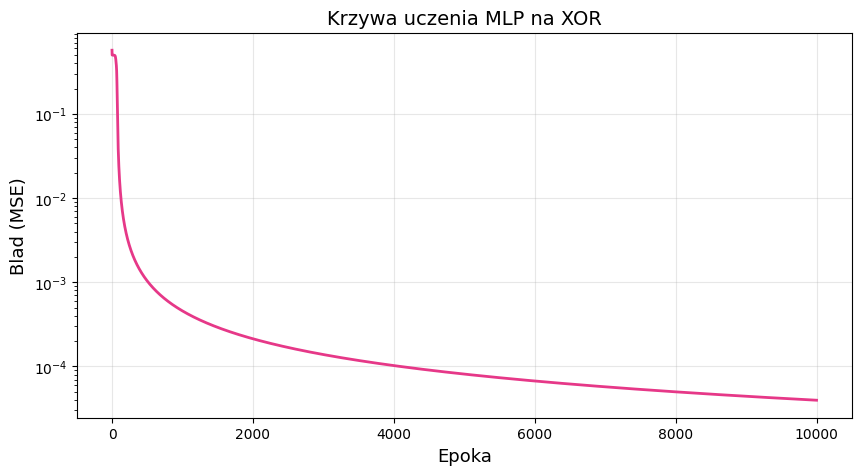

Blad spada! Na Lab 2 perceptron NIGDY nie zbiezal na XOR.
MLP z warstwa ukryta rozwiazuje to w kilku tysiacach epok.


In [9]:
# Krzywa bledu
plt.figure(figsize=(10, 5))
plt.plot(error_history, color='#E63888', linewidth=2)
plt.xlabel('Epoka', fontsize=13)
plt.ylabel('Blad (MSE)', fontsize=13)
plt.title('Krzywa uczenia MLP na XOR', fontsize=14)
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

print("Blad spada! Na Lab 2 perceptron NIGDY nie zbiezal na XOR.")
print("MLP z warstwa ukryta rozwiazuje to w kilku tysiacach epok.")

In [10]:
# Weryfikacja -- sprawdzamy kazdy przypadek XOR
print("=== Test wytrenowanego MLP na XOR ===")
print(f"{'Wejscie':>10}  {'Oczekiwane':>12}  {'Wyjscie sieci':>15}  {'Klasyfikacja':>14}")
print("-" * 60)

all_correct = True
for i in range(len(X_xor)):
    x = np.concatenate([[1], X_xor[i]])
    y_pred, _, _, _, _ = mlp_forward(x, W1_trained, W2_trained, beta=1.0)
    
    # Klasyfikacja: >0.9 -> 1, <0.1 -> 0
    if y_pred[0] > 0.9:
        klasa = 1
    elif y_pred[0] < 0.1:
        klasa = 0
    else:
        klasa = "?"
        all_correct = False
    
    ok = "OK" if klasa == y_xor[i] else "ZLE"
    if klasa != y_xor[i]:
        all_correct = False
    print(f"{str(X_xor[i]):>10}  {y_xor[i]:>12}  {y_pred[0]:>15.6f}  {str(klasa):>10}  [{ok}]")

print()
if all_correct:
    print("SUKCES! MLP nauczyl sie XOR -- to czego perceptron NIE MOGL.")
else:
    print("Jeszcze nie idealnie -- sprobuj wiecej epok lub inny learning rate.")

=== Test wytrenowanego MLP na XOR ===
   Wejscie    Oczekiwane    Wyjscie sieci    Klasyfikacja
------------------------------------------------------------
     [0 0]             0         0.003886           0  [OK]
     [0 1]             1         0.994884           1  [OK]
     [1 0]             1         0.994899           1  [OK]
     [1 1]             0         0.003486           0  [OK]

SUKCES! MLP nauczyl sie XOR -- to czego perceptron NIE MOGL.


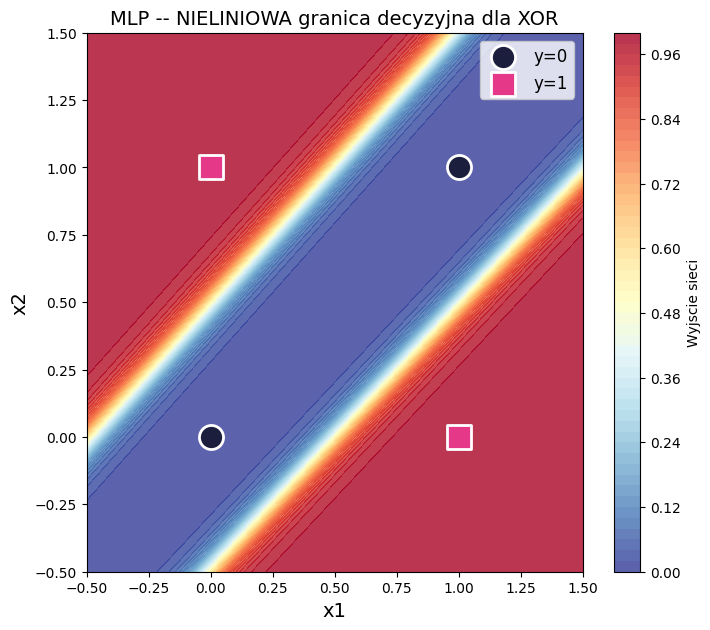

Perceptron rysuje prosta. MLP rysuje KRZYWIZNE.
Dlatego MLP umie XOR -- jego granica decyzyjna moze byc dowolnego ksztaltu.


In [11]:
# Wizualizacja granicy decyzyjnej MLP -- to jest NIELINIOWA!
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
Z = np.zeros(xx.shape)

for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        x_in = np.array([1, xx[i, j], yy[i, j]])
        y_out, _, _, _, _ = mlp_forward(x_in, W1_trained, W2_trained, beta=1.0)
        Z[i, j] = y_out[0]

plt.figure(figsize=(8, 7))
plt.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r', alpha=0.8)
plt.colorbar(label='Wyjscie sieci')
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1],
            c='#1B1E3D', marker='o', s=300, edgecolor='white', linewidth=2, label='y=0', zorder=5)
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1],
            c='#E63888', marker='s', s=300, edgecolor='white', linewidth=2, label='y=1', zorder=5)
plt.xlabel('x1', fontsize=14)
plt.ylabel('x2', fontsize=14)
plt.title('MLP -- NIELINIOWA granica decyzyjna dla XOR', fontsize=14)
plt.legend(fontsize=12)
plt.show()

print("Perceptron rysuje prosta. MLP rysuje KRZYWIZNE.")
print("Dlatego MLP umie XOR -- jego granica decyzyjna moze byc dowolnego ksztaltu.")

---

# Zadania do samodzielnego wykonania

## Zadanie 1: Implementacja forward pass (funkcja `mlp()`)

Zaimplementuj funkcję `mlp(x, w1, w2, beta)` zgodnie z architekturą z instrukcji:

- **2 wejścia** (x1, x2)
- **2 neurony ukryte** z funkcją aktywacji **tanh** (bipolarna)
- **1 neuron wyjściowy** z funkcją aktywacji **sigmoid** (unipolarna)
- Implementacja wektorowo-macierzowa (numpy)
- Funkcja zwraca: odpowiedź sieci **oraz** wszystkie składniki potrzebne do obliczania pochodnych (wyjścia warstwy ukrytej)

**Protips z instrukcji:**
1. Wejście dla warstwy ukrytej to x = [1, x1, x2] (x0=1 to bias)
2. Wejście dla warstwy wyjściowej to v = [1, v1, v2] (v0=1 to bias)
3. Do obliczenia pochodnych w backpropagation potrzebne będą wyjścia warstwy ukrytej

In [13]:
import numpy as np

def sigmoid(x, beta):
    return 1.0 / (1.0 + np.exp(-beta * x))

def tanh(x, beta):
    return np.tanh(beta * x)

# x - sygnal wejsciowy [1, x1, x2, ..., xN]
# w1 - wagi warstwy ukrytej, macierz (K x N+1)
# w2 - wagi warstwy wyjsciowej, wektor (1 x K+1)
# beta - parametr funkcji aktywacji
def mlp(x, w1, w2, beta):
    
    # 1. Wyjścia warstwy ukrytej
    v_hidden = tanh(w1 @ x, beta)
    
    # 2. Dodanie biasu
    v = np.concatenate(([1], v_hidden))
    
    # 3. Wyjście sieci
    y = sigmoid(w2 @ v, beta)
    
    # 4. Zwracamy wyniki
    return y, v, v_hidden


# Test
np.random.seed(0)
w1_test = np.random.randn(2, 3) * 0.5
w2_test = np.random.randn(1, 3) * 0.5

result = mlp(np.array([1, 0, 1]), w1_test, w2_test, beta=1.0)
print(f"Wyjscie sieci: {result[0]}")

Wyjscie sieci: [0.59379038]


## Zadanie 2: Implementacja backpropagation + trening XOR

Zaimplementuj algorytm propagacji wstecznej dla sieci z Zadania 1. Dwa warianty aktualizacji wag:

1. **`train_sample()`** — aktualizacja wag po **każdej próbce** uczącej
2. **`train_epoch()`** — aktualizacja wag po **epoce** (po przetworzeniu wszystkich próbek)

Następnie:
- Wytrenuj sieć na danych **XOR** (max 100 000 epok lub błąd klasyfikacji = 0)
- Stwórz **wykres** zmiany błędu w zależności od epoki
- Zasady klasyfikacji: wyjście > 0.9 → klasa 1, wyjście < 0.1 → klasa 0

**Protips z instrukcji:**
1. Zamień zerowe sygnały wejściowe na niezerowe: `xx = np.array([[1,-1,-1],[1,-1,1],[1,1,-1],[1,1,1]])`
2. Gradient dla warstwy ukrytej powinien mieć rozmiar (K, N+1) = (2, 3)
3. Przy aktualizacji po epoce — akumuluj gradienty, aktualizuj na końcu

**Pochodne:**
```python
def sigmoid_diff(y, beta):
    return beta * y * (1 - y)

def tanh_diff(y, beta):
    return beta * (1 - y * y)
```

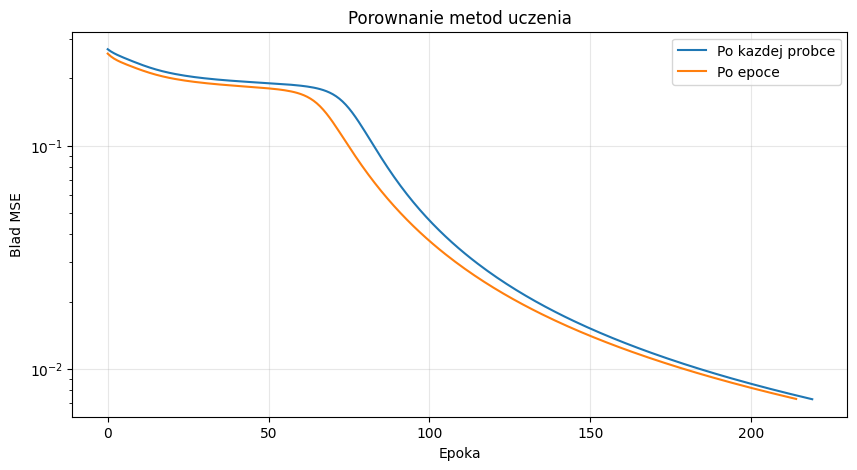

In [16]:
import numpy as np
import matplotlib.pyplot as plt

xx = np.array([[1, -1, -1],
               [1, -1,  1],
               [1,  1, -1],
               [1,  1,  1]])

d = np.array([0, 1, 1, 0])

def sigmoid(x, beta):
    return 1.0 / (1.0 + np.exp(-beta * x))

def tanh(x, beta):
    return np.tanh(beta * x)

def sigmoid_diff(y, beta):
    return beta * y * (1 - y)

def tanh_diff(y, beta):
    return beta * (1 - y * y)

def mlp(x, w1, w2, beta):

    v_hidden = tanh(w1 @ x, beta)
    v = np.concatenate(([1], v_hidden))
    y = sigmoid(w2 @ v, beta)
    return y, v, v_hidden

def train_sample(xx, d, eta, beta):

    K = 2
    N = 2
    np.random.seed(0)
    w1 = np.random.randn(K, N+1) * 0.5
    w2 = np.random.randn(1, K+1) * 0.5
    errors = []

    for epoch in range(100000):
        mse = 0
        class_error = 0

        for i in range(len(xx)):
            x = xx[i]
            target = d[i]
            y, v, v_hidden = mlp(x, w1, w2, beta)
            e = target - y
            mse += e**2
            if (y > 0.9 and target == 1) or (y < 0.1 and target == 0):
                pass
            else:
                class_error += 1

            delta_out = e * sigmoid_diff(y, beta)
            delta_hidden = tanh_diff(v_hidden, beta) * (w2[:,1:].T * delta_out).flatten()
            grad_w2 = delta_out * v
            grad_w1 = delta_hidden.reshape(-1,1) @ x.reshape(1,-1)
            w2 += eta * grad_w2
            w1 += eta * grad_w1

        mse /= len(xx)
        errors.append(mse)
        if class_error == 0:
            break
    return errors

def train_epoch(xx, d, eta, beta):
    K = 2
    N = 2
    np.random.seed(0)
    w1 = np.random.randn(K, N+1) * 0.5
    w2 = np.random.randn(1, K+1) * 0.5
    errors = []

    for epoch in range(100000):
        mse = 0
        class_error = 0
        grad_w1_sum = np.zeros_like(w1)
        grad_w2_sum = np.zeros_like(w2)

        for i in range(len(xx)):
            x = xx[i]
            target = d[i]
            y, v, v_hidden = mlp(x, w1, w2, beta)
            e = target - y
            mse += e**2
            if (y > 0.9 and target == 1) or (y < 0.1 and target == 0):
                pass
            else:
                class_error += 1
            delta_out = e * sigmoid_diff(y, beta)
            delta_hidden = tanh_diff(v_hidden, beta) * (w2[:,1:].T * delta_out).flatten()
            grad_w2 = delta_out * v
            grad_w1 = delta_hidden.reshape(-1,1) @ x.reshape(1,-1)
            grad_w2_sum += grad_w2
            grad_w1_sum += grad_w1

        w2 += eta * grad_w2_sum
        w1 += eta * grad_w1_sum

        mse /= len(xx)
        errors.append(mse)

        if class_error == 0:
            break

    return errors


errors_sample = train_sample(xx, d, eta=0.5, beta=1.0)
errors_epoch = train_epoch(xx, d, eta=0.5, beta=1.0)

plt.figure(figsize=(10,5))

plt.plot(errors_sample, label="Po kazdej probce")
plt.plot(errors_epoch, label="Po epoce")

plt.xlabel("Epoka")
plt.ylabel("Blad MSE")
plt.title("Porownanie metod uczenia")

plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

---

## Sprawdź, co umiesz — pytania kontrolne

1. **Czym różni się MLP od pojedynczego perceptronu?**
2. **Dlaczego używamy sigmoid/tanh zamiast funkcji progowej?**
3. **Co robi forward pass, a co backpropagation?**
4. **Dlaczego potrzebujemy pochodnych funkcji aktywacyjnych?**
5. **Jaka jest różnica między aktualizacją wag po próbce a po epoce?**
6. **Dlaczego zerowe wejścia XOR (0,0) warto zamienić na (-1,-1)?**

---

## Co dalej?

- **Lab 4**: TensorFlow/PyTorch — te same koncepty, ale framework robi backpropagation za Ciebie
- **Lab 5**: CNN — sieci konwolucyjne, które rozumieją sąsiedztwo pikseli

MLP + backpropagation to fundament całego deep learningu. Każda nowoczesna sieć neuronowa używa propagacji wstecznej do uczenia się — różni się tylko architekturą.